<img src="./logo_UNSAM.jpg" align="right" width="150" /> 



# Funciones Senoidales, Teorema de N-S y Ploteo en Python
### Por: Francisco Weitzman

# Introduccion

En este trabajo práctico vamos a combinar las siguientes tareas:
1. Empezar a usar python
2. Aprender a llamar librerías, funciones matemáticas y de código, y por último plotear o graficar los resultados
3. Entender y experimentar con el teorema de Nyquist-Shannon


In [14]:
# -*- coding: utf-8 -*-
"""
Created on Wed Aug 12 20:31:32 2026
@author: Fran
"""
import matplotlib.pyplot as plt
import numpy as np
#%% Definiciones
fs = 1000 # Hz
N = 1000 # Muestras
vmax = 1.5 # [V]
dc = 0 # continua [V]
ff = 1 # frecuencia de senoidal [Hz]
ph = 0 # fase [rad]
n = np.arange(0,N-1) # [u]
#%% Funciones
def mi_funcion_sen(vmax : float, dc: float, ff: float, ph: float, fs: float, colour: str):
    
    tt = n/fs
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc # tt = n*t_sampling
    plt.plot(tt, xx, color=colour,label=f'vmax={vmax}, ff={ff} Hz')
    return(tt, xx)





Como podemos ver, en mi código creé una funcion, unos parámetros y llamé a las librerías matplotlib y numpy.
Además, creé una funcion "mi_funcion_sen" que recibe unos parámetros y devuelve un vector de tiempos discretos con un vector que guarda la información del valor del seno con nuestros parámetros (Vmax, phase, etc.) indexado con los tiempos de muestreo tt.

primero vamos a probar una funcion seno de 1Hz:

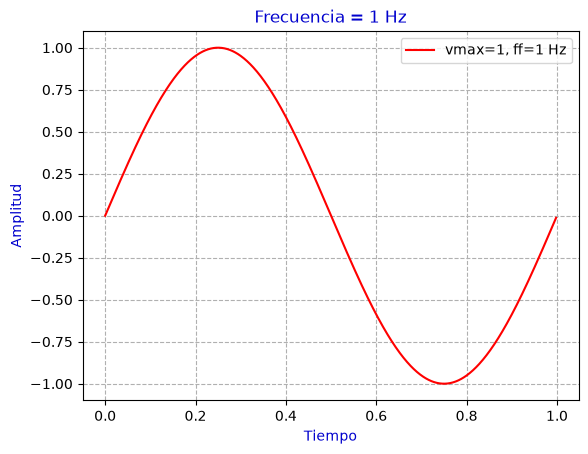

In [23]:
#%% Script
ff = 1
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = ff, ph=0, fs = fs, colour = 'red')
plt.xlabel("Tiempo", color='mediumblue')
plt.ylabel("Amplitud", color='mediumblue')
plt.title(f'Frecuencia = {ff} Hz', color='mediumblue')
plt.grid(color='#b0b0b0', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()


Bien! ya usamos varias cosas: Funciones de python, las librerías de python, la funcion seno y aprendí (con un poco de ayuda de la IA) a tener las funciones que vuelven lindos a los gráficos ✨
Vamos con el teorema de N-S y algunas implicancias y sus explicaciones. Para eso, vamos a usar el siguiente código y usar las siguientes frecuencias:  
f1 = 500Hz  
f2 = 999Hz  
f3 = 1001Hz


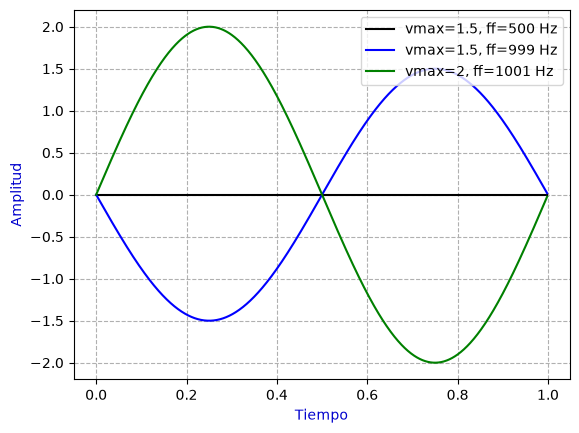

In [22]:
tt, xx = mi_funcion_sen( vmax = 1.5, dc = 0, ff = 500 , ph=0, fs = fs, colour='black')
tt, xx = mi_funcion_sen( vmax = 1.5, dc = 0, ff = 999 , ph=0, fs = fs, colour='blue')
tt, xx = mi_funcion_sen( vmax = 2, dc = 0, ff = 1001 , ph=0, fs = fs, colour='green')
plt.xlabel("Tiempo", color='mediumblue')
plt.ylabel("Amplitud", color='mediumblue')
plt.grid(color='#b0b0b0', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

Como se puede apreciar, la frecuencia "1" da una funcion constante como resultado.  
La frecuencia "2" da una funcion sen(-2.pi.t) = -sen(2.pi.t.1)  
Por ultimo, la frecuencia "3" da una funcion sen(2.pi.t.1)  
Los ultimos dos casos son consecuencia de la periodicidad que se produce en el dominio de las frecuencias por haber discretizado el dominio temporal. La frecuencia de repeticion en el dominio frecuencial es de fs. En este caso, fs = 1000Hz, por eso vemos que el Sen de 1Hz es igual al de 1001Hz, porque 1Hz = 1001 - fs. Lo mismo con la frecuencia -1Hz y 999Hz  

Ahora bien, el caso de los 500Hz es especial. El teorema de N-S nos dice que
> \begin{equation}
f_{máx} \lt \frac{f_s}{2}
\end{equation}

En este caso, al usar la frecuencia 500Hz, denominada 'frecuencia de Nyquist', por ser exactamente la mitad de la fs, tiene un problema y es que:  
\begin{equation}
V_{máx} \times \sin({2 \pi \times f_f \times \frac{n}{f_s}+ \phi})
\end{equation}  
\begin{equation}
V_{máx} \times \sin({2 \pi \times \frac{f_s}{2} \times \frac{n}{f_s}+ \phi})
\end{equation}  
\begin{equation}
V_{máx} \times \sin({\pi \times n+ \phi})
\end{equation}  
Que nos da "0" para todas las muestras. Para 1000Hz y multiplos enteros de 500Hz también, ya sea porque se quiera pensar por la periodicidad debida a la discretizacion del dominio temporal, o porque en aquel seno, en el argumento van a seguir habiendo multiplos enteros de pi. Si ploteamos la frecuencia de 500Hz sola,

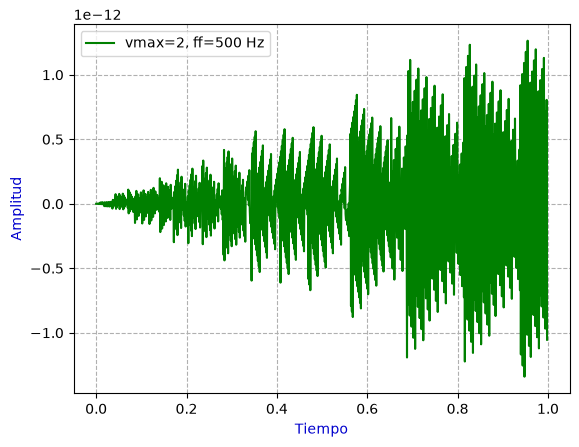

In [24]:
tt, xx = mi_funcion_sen( vmax = 2, dc = 0, ff = 500 , ph=0, fs = fs, colour='green')
plt.xlabel("Tiempo", color='mediumblue')
plt.ylabel("Amplitud", color='mediumblue')
plt.grid(color='#b0b0b0', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

vemos que, aunque sea muy chiquito, hay un ruido importante y creciente con t. Eso, de todos modos, se debe a errores numéricos del tipo "punto flotante", y es que deberían dar 0, pero como python no tiene la posibilidad de guardar los infinitos valores infinitesimales (por obvios motivos del numero irracional y la limitación de un sistema físico), aparece ese error que, aunque pequeño, se puede apreciar si se lo plotea solo. Nótese la magnitud que es del orden de 10^-12.